In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df = pd.read_csv('merged_gram_reservoir.csv')

df1 = df.drop('crop_name', axis=1)

In [3]:
for state, df_state in df1.groupby('state_name'):
    var_name = 'df_' + state.replace(' ', '_')
    globals()[var_name] = df_state
    
created_dfs = {name: eval(name).shape for name in globals() if name.startswith('df_')}
created_dfs

{'df_state': (8401, 11),
 'df_Andhra_Pradesh': (8401, 11),
 'df_Chhattisgarh': (8401, 11),
 'df_Gujarat': (8401, 11),
 'df_Jharkhand': (7670, 11),
 'df_Karnataka': (8401, 11),
 'df_Madhya_Pradesh': (8036, 11),
 'df_Maharashtra': (8401, 11),
 'df_Odisha': (2192, 11),
 'df_Rajasthan': (8401, 11),
 'df_Tamil_Nadu': (5845, 11),
 'df_Telangana': (8401, 11),
 'df_Uttar_Pradesh': (8401, 11),
 'df_Uttarakhand': (8401, 11),
 'df_West_Bengal': (8401, 11)}

In [4]:
for var_name in list(globals()):
    if var_name.startswith('df_') and isinstance(globals()[var_name], pd.DataFrame):
        if 'state_name' in globals()[var_name].columns:
            globals()[var_name] = globals()[var_name].drop(columns='state_name')
            

In [5]:
df_andp = df_Andhra_Pradesh

In [6]:
df_andp

,apy_item_interval_start,temperature_recorded_date,state_temperature_max_val,state_temperature_min_val,state_rainfall_val,yield,FRL,Live Cap FRL,Level,Current Live Storage
0,2000,2000-01-01,30.38,14.47,0.00,1.22615,152.296667,2.838333,266.300000,6.390000
1,2000,2000-01-02,30.04,13.96,0.00,1.22615,152.296667,2.838333,266.180000,6.330000
2,2000,2000-01-03,29.92,12.98,0.00,1.22615,152.296667,2.838333,266.090000,6.286000
3,2000,2000-01-04,29.98,12.23,0.00,1.22615,152.296667,2.838333,266.030000,6.257000
4,2000,2000-01-05,29.77,13.24,0.00,1.22615,152.296667,2.838333,265.970000,6.228000
...,...,...,...,...,...,...,...,...,...,...
8396,2022,2022-12-27,32.37,18.92,0.57,1.42080,152.296667,2.838333,148.827667,1.761303
8397,2022,2022-12-28,33.36,18.66,0.04,1.42080,152.296667,2.838333,148.764667,1.746027
8398,2022,2022-12-29,33.23,18.37,0.00,1.42080,152.296667,2.838333,148.680000,1.726320
8399,2022,2022-12-30,32.78,16.24,0.00,1.42080,152.296667,2.838333,148.608667,1.711617


In [7]:
df_andp.columns

Index(['apy_item_interval_start', 'temperature_recorded_date',
       'state_temperature_max_val', 'state_temperature_min_val',
       'state_rainfall_val', 'yield', 'FRL', 'Live Cap FRL', 'Level',
       'Current Live Storage'],
      dtype='object')

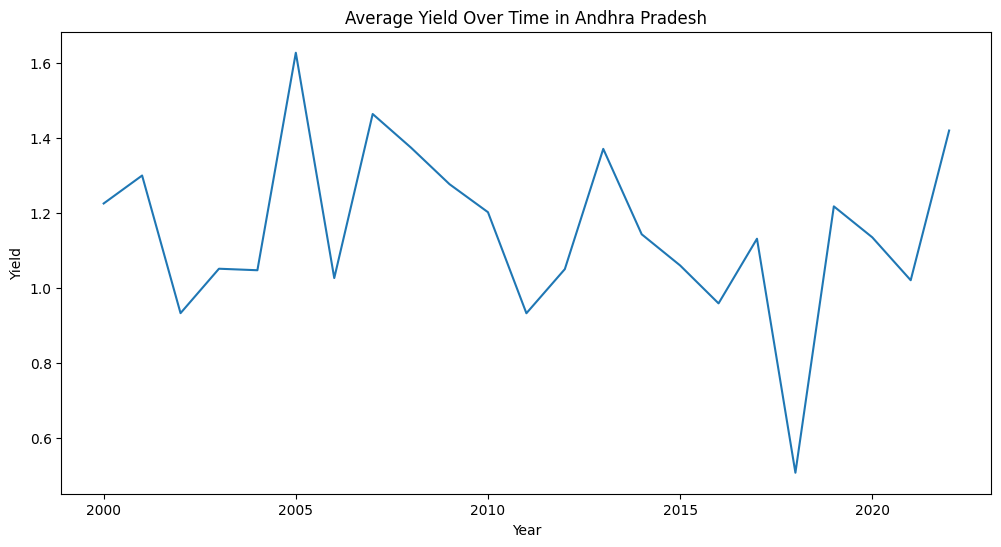

In [8]:
yiearly_yield = df_andp.groupby('apy_item_interval_start')['yield'].mean().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(yiearly_yield['apy_item_interval_start'], yiearly_yield['yield'])
plt.title('Average Yield Over Time in Andhra Pradesh')
plt.xlabel('Year')
plt.ylabel('Yield')
plt.show()


In [9]:
df_andph = df_andp.drop(columns =['FRL', 'Live Cap FRL','Current Live Storage'], axis=1)
df_andph

,apy_item_interval_start,temperature_recorded_date,state_temperature_max_val,state_temperature_min_val,state_rainfall_val,yield,Level
0,2000,2000-01-01,30.38,14.47,0.00,1.22615,266.300000
1,2000,2000-01-02,30.04,13.96,0.00,1.22615,266.180000
2,2000,2000-01-03,29.92,12.98,0.00,1.22615,266.090000
3,2000,2000-01-04,29.98,12.23,0.00,1.22615,266.030000
4,2000,2000-01-05,29.77,13.24,0.00,1.22615,265.970000
...,...,...,...,...,...,...,...
8396,2022,2022-12-27,32.37,18.92,0.57,1.42080,148.827667
8397,2022,2022-12-28,33.36,18.66,0.04,1.42080,148.764667
8398,2022,2022-12-29,33.23,18.37,0.00,1.42080,148.680000
8399,2022,2022-12-30,32.78,16.24,0.00,1.42080,148.608667


In [10]:
df_andph.columns

Index(['apy_item_interval_start', 'temperature_recorded_date',
       'state_temperature_max_val', 'state_temperature_min_val',
       'state_rainfall_val', 'yield', 'Level'],
      dtype='object')

In [ ]:
df_andph.set_index('temperature_recorded_date', inplace=True)
df_andph['Week'] = df_andph[''].week

df_andph_weekly = df_andph.groupby('Week').mean().reset_index()
df_andph_weekly

AttributeError: 'Index' object has no attribute 'isocalendar'